# 🧠🤖 第3周-Day7 复习日：大模型训练全景

## 🎯 复习目标：串联W1-W3关键概念

今天是第3周的复习日，我们将串联前3周的核心知识：
- **W1**：Transformer基础架构（自注意力、位置编码等）
- **W2**：Transformer深入理解（推理优化、Tokenizer等）
- **W3**：大模型训练全景（预训练、SFT、RLHF、DPO）

让我们用代码和可视化来巩固这些重要概念！

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import math

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK SC', 'Droid Sans Fallback', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print("🎉 第3周复习工具已就绪！")

🎉 第3周复习工具已就绪！


## 📊 W1-W3 知识点串联图

/tmp/ipykernel_72865/219624567.py:73: UserWarning: Glyph 108 (l) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_72865/219624567.py:73: UserWarning: Glyph 112 (p) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_72865/219624567.py:73: UserWarning: Glyph 87 (W) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_72865/219624567.py:73: UserWarning: Glyph 101 (e) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_72865/219624567.py:73: UserWarning: Glyph 107 (k) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_72865/219624567.py:73: UserWarning: Glyph 49 (1) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_72865/219624567.py:73: UserWarning: Glyph 50 (2) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_72865/219624567.py:73: UserWarning: Glyph 51 (3) missing from font(s) Droid Sans Fallback.
 

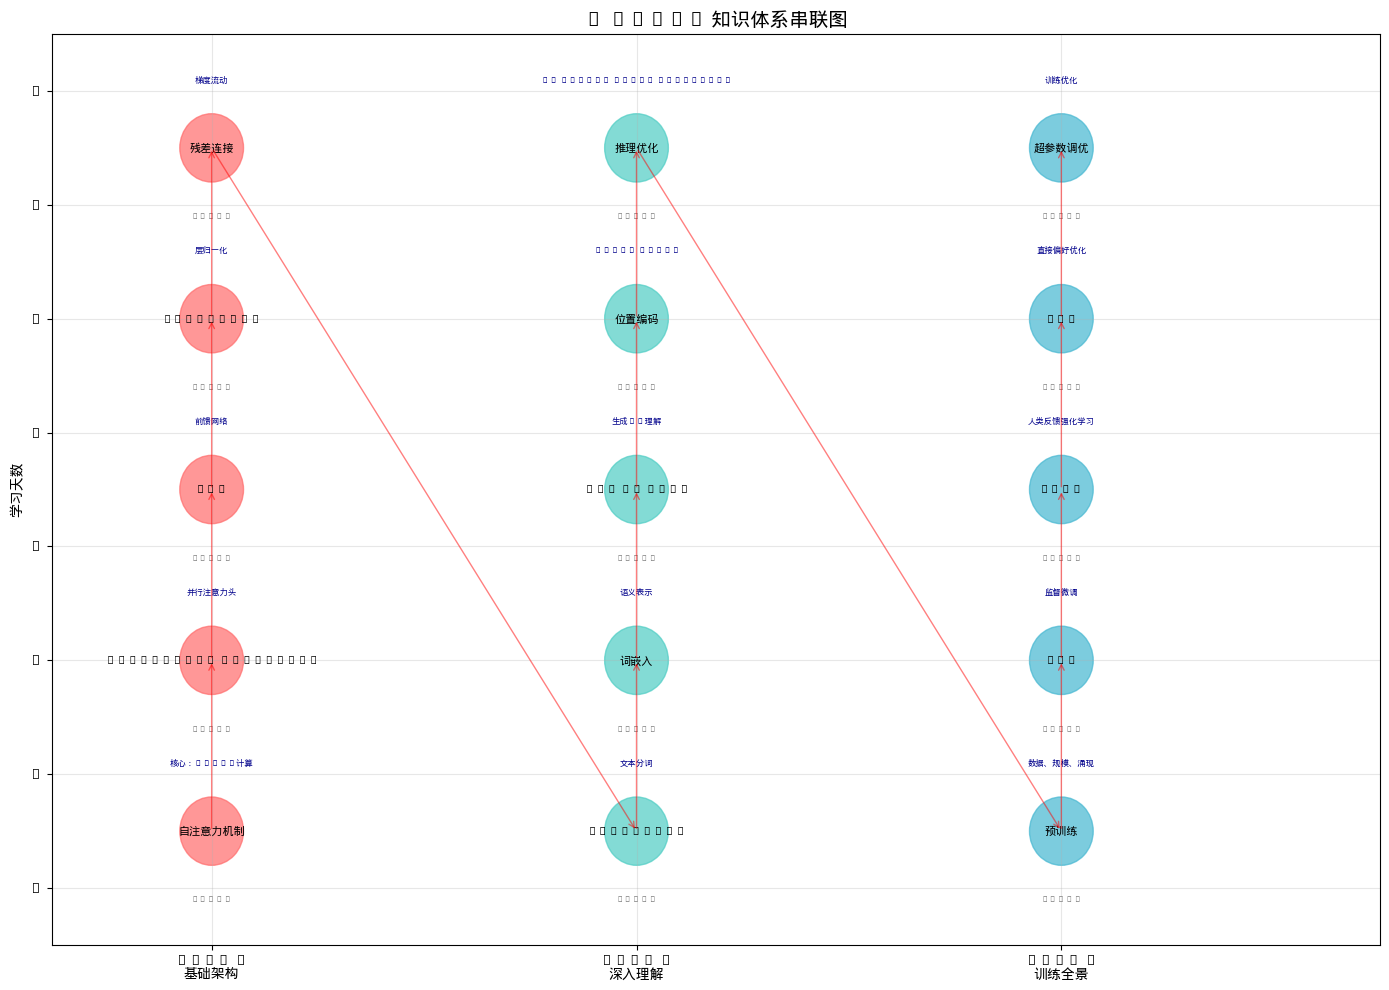

In [2]:
def create_knowledge_map():
    """创建W1-W3知识串联图"""
    fig, ax = plt.subplots(1, 1, figsize=(14, 10))
    
    # 定义知识点
    knowledge_points = [
        # W1 - Transformer基础
        ("自注意力机制", 1, 1, "W1-D1", "核心：Q,K,V计算"),
        ("Multi-Head Attention", 1, 2, "W1-D2", "并行注意力头"),
        ("FFN", 1, 3, "W2-D1", "前馈网络"),
        ("LayerNorm", 1, 4, "W2-D1", "层归一化"),
        ("残差连接", 1, 5, "W2-D1", "梯度流动"),
        
        # W2 - 深入理解
        ("Tokenizer", 2, 1, "W2-D2", "文本分词"),
        ("词嵌入", 2, 2, "W2-D2", "语义表示"),
        ("GPT vs BERT", 2, 3, "W2-D3", "生成vs理解"),
        ("位置编码", 2, 4, "W2-D4", "RoPE, ALiBi"),
        ("推理优化", 2, 5, "W2-D5", "KV Cache, Flash Attention"),
        
        # W3 - 训练全景
        ("预训练", 3, 1, "W3-D1", "数据、规模、涌现"),
        ("SFT", 3, 2, "W3-D2", "监督微调"),
        ("RLHF", 3, 3, "W3-D3", "人类反馈强化学习"),
        ("DPO", 3, 4, "W3-D4", "直接偏好优化"),
        ("超参数调优", 3, 5, "W3-D5", "训练优化"),
    ]
    
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
    
    for i, (name, week, day, day_label, desc) in enumerate(knowledge_points):
        x = (week - 1) * 4 + 1
        y = day * 1.5
        color = colors[(week-1) % len(colors)]
        
        # 绘制节点
        circle = plt.Circle((x, y), 0.3, color=color, alpha=0.7)
        ax.add_patch(circle)
        
        # 添加标签
        ax.text(x, y, name, ha='center', va='center', fontsize=8, weight='bold')
        ax.text(x, y-0.6, day_label, ha='center', va='center', fontsize=6, color='gray')
        ax.text(x, y+0.6, desc, ha='center', va='center', fontsize=6, color='darkblue')
    
    # 添加连接线
    connections = [
        # W1内部连接
        ((1, 1), (1, 2)), ((1, 2), (1, 3)), ((1, 3), (1, 4)), ((1, 4), (1, 5)),
        # W2内部连接
        ((2, 1), (2, 2)), ((2, 2), (2, 3)), ((2, 3), (2, 4)), ((2, 4), (2, 5)),
        # W3内部连接
        ((3, 1), (3, 2)), ((3, 2), (3, 3)), ((3, 3), (3, 4)), ((3, 4), (3, 5)),
        # 跨周连接
        ((1, 5), (2, 1)), ((2, 5), (3, 1)),
    ]
    
    for (week1, day1), (week2, day2) in connections:
        x1 = (week1 - 1) * 4 + 1
        y1 = day1 * 1.5
        x2 = (week2 - 1) * 4 + 1
        y2 = day2 * 1.5
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                   arrowprops=dict(arrowstyle='->', color='red', alpha=0.5, lw=1))
    
    ax.set_xlim(-0.5, 12)
    ax.set_ylim(0.5, 8.5)
    ax.set_xticks([1, 5, 9])
    ax.set_xticklabels(['Week 1\n基础架构', 'Week 2\n深入理解', 'Week 3\n训练全景'])
    ax.set_ylabel('学习天数')
    ax.set_title('🧠 W1-W3 知识体系串联图', fontsize=14, weight='bold')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

create_knowledge_map()

## 🔧 核心概念代码演示

### 1. 自注意力机制（W1核心）

🎯 自注意力机制演示
输入矩阵 X: 
[[1 0 0]
 [0 1 0]
 [0 0 1]
 [1 1 0]]

Q (查询): 
[[1 0]
 [0 1]
 [0 0]
 [1 1]]

K (键): 
[[0 1]
 [1 0]
 [0 0]
 [1 1]]

V (值): 
[[1 0]
 [0 1]
 [1 1]
 [1 1]]

注意力分数 (Q @ K.T): 
[[0 1 0 1]
 [1 0 0 1]
 [0 0 0 0]
 [1 1 0 2]]

注意力权重: 
[[0.13447071 0.36552929 0.13447071 0.36552929]
 [0.36552929 0.13447071 0.13447071 0.36552929]
 [0.25       0.25       0.25       0.25      ]
 [0.19661193 0.19661193 0.07232949 0.53444665]]

最终输出: 
[[0.63447071 0.86552929]
 [0.86552929 0.63447071]
 [0.75       0.75      ]
 [0.80338807 0.80338807]]



/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 108 (l) missing from font(s) Droid Sans Fallback.
  fig.canvas.draw()
/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 112 (p) missing from font(s) Droid Sans Fallback.
  fig.canvas.draw()
/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 65 (A) missing from font(s) Droid Sans Fallback.
  fig.canvas.draw()
/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 73 (I) missing from font(s) Droid Sans Fallback.
  fig.canvas.draw()
/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 48 (0) missing from font(s) Droid Sans Fallback.
  fig.canvas.draw()
/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 46 (.) missing from font(s) Droid S

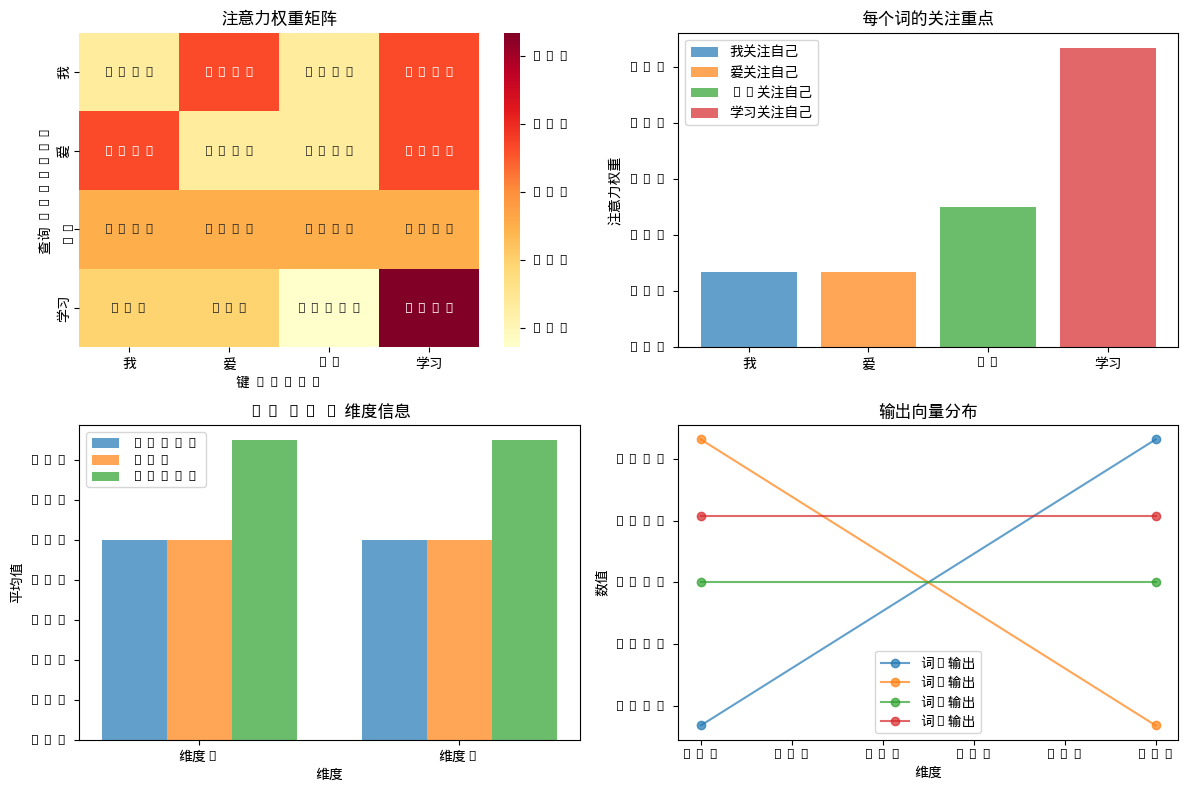

In [4]:
def self_attention_demo():
    """演示自注意力机制"""
    print("🎯 自注意力机制演示")
    
    # 简化的输入向量
    X = np.array([
        [1, 0, 0],  # "我"
        [0, 1, 0],  # "爱"
        [0, 0, 1],  # "AI"
        [1, 1, 0]   # "学习"
    ])
    
    # 模拟Q, K, V权重 — 统一为 (3, 2) 维度
    Wq = np.array([[1, 0], [0, 1], [0, 0]])
    Wk = np.array([[0, 1], [1, 0], [0, 0]])  # 修复：从 (2,3) 改为 (3,2)
    Wv = np.array([[1, 0], [0, 1], [1, 1]])
    
    Q = X @ Wq  # (4,3) @ (3,2) -> (4,2)
    K = X @ Wk  # (4,3) @ (3,2) -> (4,2)
    V = X @ Wv  # (4,3) @ (3,2) -> (4,2)
    
    print(f"输入矩阵 X: \n{X}\n")
    print(f"Q (查询): \n{Q}\n")
    print(f"K (键): \n{K}\n")
    print(f"V (值): \n{V}\n")
    
    # 计算注意力分数
    scores = Q @ K.T  # (4,2) @ (2,4) -> (4,4)
    print(f"注意力分数 (Q @ K.T): \n{scores}\n")
    
    # Softmax归一化
    def softmax(x):
        exp_x = np.exp(x - np.max(x, axis=-1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=-1, keepdims=True)
    
    attention_weights = softmax(scores)
    print(f"注意力权重: \n{attention_weights}\n")
    
    # 加权求和得到输出
    output = attention_weights @ V  # (4,4) @ (4,2) -> (4,2)
    print(f"最终输出: \n{output}\n")
    
    # 可视化
    plt.figure(figsize=(12, 8))
    
    plt.subplot(2, 2, 1)
    plt.title("注意力权重矩阵")
    sns.heatmap(attention_weights, annot=True, cmap='YlOrRd', 
                xticklabels=['我', '爱', 'AI', '学习'],
                yticklabels=['我', '爱', 'AI', '学习'])
    plt.xlabel("键 (Key)")
    plt.ylabel("查询 (Query)")
    
    plt.subplot(2, 2, 2)
    plt.title("每个词的关注重点")
    words = ['我', '爱', 'AI', '学习']
    for i, word in enumerate(words):
        plt.bar(word, attention_weights[i, i], alpha=0.7, label=f'{word}关注自己')
    plt.ylabel("注意力权重")
    plt.legend()
    
    plt.subplot(2, 2, 3)
    plt.title("Q, K, V 维度信息")
    dimensions = ['维度1', '维度2']
    Q_dims = [np.mean(Q[:, i]) for i in range(Q.shape[1])]
    K_dims = [np.mean(K[:, i]) for i in range(K.shape[1])]
    V_dims = [np.mean(V[:, i]) for i in range(V.shape[1])]
    
    x = np.arange(len(dimensions))
    width = 0.25
    plt.bar(x - width, Q_dims, width, label='Query', alpha=0.7)
    plt.bar(x, K_dims, width, label='Key', alpha=0.7)
    plt.bar(x + width, V_dims, width, label='Value', alpha=0.7)
    plt.xlabel("维度")
    plt.ylabel("平均值")
    plt.xticks(x, dimensions)
    plt.legend()
    
    plt.subplot(2, 2, 4)
    plt.title("输出向量分布")
    for i, out in enumerate(output):
        plt.plot(out, 'o-', label=f'词{i+1}输出', alpha=0.7)
    plt.xlabel("维度")
    plt.ylabel("数值")
    plt.legend()
    
    plt.tight_layout()
    plt.show()

self_attention_demo()

### 2. 位置编码演示（W2核心）

🧮 RoPE位置编码演示
位置编码矩阵形状: (50, 16)
前5个位置编码示例:
[[ 5.40302306e-01  8.41470985e-01  9.50415280e-01  3.10983593e-01
   9.95004165e-01  9.98334166e-02  9.99500042e-01  3.16175064e-02
   9.99950000e-01  9.99983333e-03  9.99995000e-01  3.16227239e-03
   9.99999500e-01  9.99999833e-04  9.99999950e-01  3.16227761e-04]
 [-4.16146837e-01  9.09297427e-01  8.06578410e-01  5.91127117e-01
   9.80066578e-01  1.98669331e-01  9.98000667e-01  6.32033979e-02
   9.99800007e-01  1.99986667e-02  9.99980000e-01  6.32451316e-03
   9.99998000e-01  1.99999867e-03  9.99999800e-01  6.32455490e-04]
 [-9.89992497e-01  1.41120008e-01  5.82753611e-01  8.12648897e-01
   9.55336489e-01  2.95520207e-01  9.95503374e-01  9.47260913e-02
   9.99550034e-01  2.99955002e-02  9.99955000e-01  9.48669068e-03
   9.99995500e-01  2.99999550e-03  9.99999550e-01  9.48683156e-04]
 [-6.53643621e-01 -7.56802495e-01  3.01137463e-01  9.53580740e-01
   9.21060994e-01  3.89418342e-01  9.92010661e-01  1.26154067e-01
   9.99200107e-01  3.99893342e

/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 108 (l) missing from font(s) Droid Sans Fallback.
  fig.canvas.draw()
/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 112 (p) missing from font(s) Droid Sans Fallback.
  fig.canvas.draw()
/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 48 (0) missing from font(s) Droid Sans Fallback.
  fig.canvas.draw()
/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 49 (1) missing from font(s) Droid Sans Fallback.
  fig.canvas.draw()
/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 50 (2) missing from font(s) Droid Sans Fallback.
  fig.canvas.draw()
/opt/code/ai-learning-notes/.venv/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 51 (3) missing from font(s) Droid S

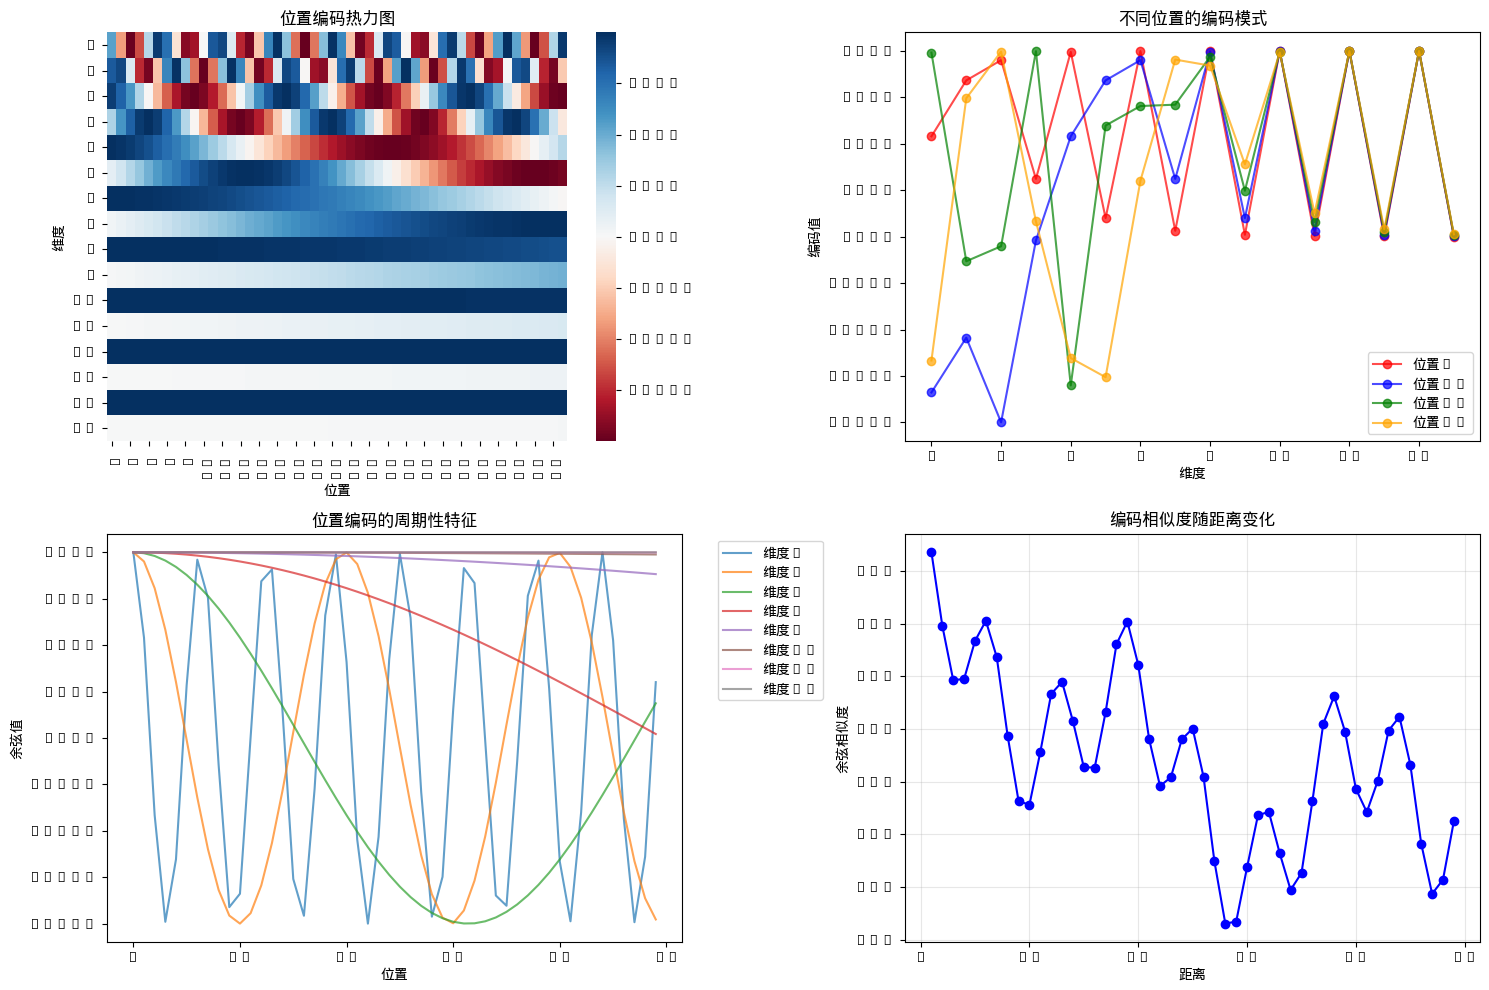

In [5]:
def positional_encoding_demo():
    """演示RoPE位置编码"""
    print("🧮 RoPE位置编码演示")
    
    def rope_encoding(pos, dim):
        """简化的RoPE位置编码"""
        encoding = np.zeros(dim)
        for i in range(0, dim, 2):
            theta = 1.0 / (10000 ** (i / dim))
            encoding[i] = np.cos(pos * theta)
            if i + 1 < dim:
                encoding[i + 1] = np.sin(pos * theta)
        return encoding
    
    # 生成不同位置编码
    max_pos = 50
    d_model = 16
    
    encodings = []
    for pos in range(1, max_pos + 1):
        encodings.append(rope_encoding(pos, d_model))
    
    encodings = np.array(encodings)
    
    print(f"位置编码矩阵形状: {encodings.shape}")
    print("前5个位置编码示例:")
    print(encodings[:5])
    
    # 可视化位置编码
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 2, 1)
    plt.title("位置编码热力图")
    sns.heatmap(encodings.T, cmap='RdBu', center=0)
    plt.xlabel("位置")
    plt.ylabel("维度")
    
    plt.subplot(2, 2, 2)
    plt.title("不同位置的编码模式")
    positions = [1, 10, 25, 40]
    colors = ['red', 'blue', 'green', 'orange']
    for pos, color in zip(positions, colors):
        plt.plot(encodings[pos-1], 'o-', label=f'位置{pos}', color=color, alpha=0.7)
    plt.xlabel("维度")
    plt.ylabel("编码值")
    plt.legend()
    
    plt.subplot(2, 2, 3)
    plt.title("位置编码的周期性特征")
    for dim in range(0, d_model, 2):
        pattern = [rope_encoding(pos, d_model)[dim] for pos in range(max_pos)]
        plt.plot(pattern, alpha=0.7, label=f'维度{dim}')
    plt.xlabel("位置")
    plt.ylabel("余弦值")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    plt.subplot(2, 2, 4)
    plt.title("编码相似度随距离变化")
    similarities = []
    for distance in range(1, max_pos):
        sim = np.dot(encodings[0], encodings[distance]) / (np.linalg.norm(encodings[0]) * np.linalg.norm(encodings[distance]))
        similarities.append(sim)
    
    plt.plot(range(1, max_pos), similarities, 'b-o')
    plt.xlabel("距离")
    plt.ylabel("余弦相似度")
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

positional_encoding_demo()

### 3. 推理优化对比（W2核心）

⚡ 推理优化方法对比


/tmp/ipykernel_72865/61202879.py:52: UserWarning: Glyph 108 (l) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_72865/61202879.py:52: UserWarning: Glyph 112 (p) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_72865/61202879.py:52: UserWarning: Glyph 75 (K) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_72865/61202879.py:52: UserWarning: Glyph 86 (V) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_72865/61202879.py:52: UserWarning: Glyph 67 (C) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_72865/61202879.py:52: UserWarning: Glyph 97 (a) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_72865/61202879.py:52: UserWarning: Glyph 99 (c) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_72865/61202879.py:52: UserWarning: Glyph 104 (h) missing from font(s) Droid Sans Fallback.
  plt.tigh

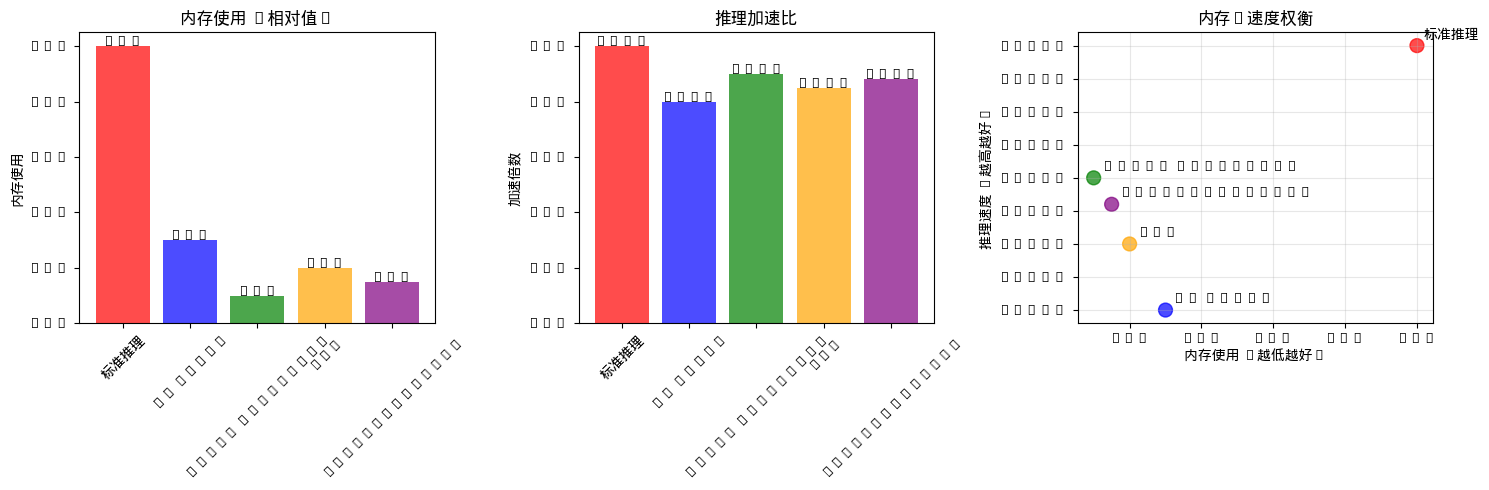


📋 推理优化方法详解:
• KV Cache: 缓存Key-Value对，避免重复计算，内存换时间
• Flash Attention: 分块计算，减少内存读写，大幅提升速度
• GQA: 分组查询注意力，平衡精度和效率
• PagedAttention: 类似GPU paging，优化内存管理


In [6]:
def inference_optimization_comparison():
    """对比不同的推理优化方法"""
    print("⚡ 推理优化方法对比")
    
    # 模拟不同的优化方法
    methods = [
        ('标准推理', 1.0, 1.0, 'baseline'),
        ('KV Cache', 0.3, 0.8, 'cache'),
        ('Flash Attention', 0.1, 0.9, 'flash'),
        ('GQA', 0.2, 0.85, 'gqa'),
        ('PagedAttention', 0.15, 0.88, 'paged')
    ]
    
    names = [m[0] for m in methods]
    memory_usage = [m[1] for m in methods]
    speedup = [m[2] for m in methods]
    colors = ['red', 'blue', 'green', 'orange', 'purple']
    
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    bars = plt.bar(names, memory_usage, color=colors, alpha=0.7)
    plt.title('内存使用 (相对值)')
    plt.ylabel('内存使用')
    plt.xticks(rotation=45)
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom')
    
    plt.subplot(1, 3, 2)
    bars = plt.bar(names, speedup, color=colors, alpha=0.7)
    plt.title('推理加速比')
    plt.ylabel('加速倍数')
    plt.xticks(rotation=45)
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}x', ha='center', va='bottom')
    
    plt.subplot(1, 3, 3)
    # 散点图：内存 vs 速度
    plt.scatter(memory_usage, speedup, s=100, c=colors, alpha=0.7)
    for i, name in enumerate(names):
        plt.annotate(name, (memory_usage[i], speedup[i]), 
                    xytext=(5, 5), textcoords='offset points')
    plt.xlabel('内存使用 (越低越好)')
    plt.ylabel('推理速度 (越高越好)')
    plt.title('内存-速度权衡')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 优化方法详细说明
    print("\n📋 推理优化方法详解:")
    explanations = {
        'KV Cache': '缓存Key-Value对，避免重复计算，内存换时间',
        'Flash Attention': '分块计算，减少内存读写，大幅提升速度',
        'GQA': '分组查询注意力，平衡精度和效率',
        'PagedAttention': '类似GPU paging，优化内存管理'
    }
    
    for method, desc in explanations.items():
        print(f"• {method}: {desc}")

inference_optimization_comparison()

### 4. 训练流程可视化（W3核心）

🚀 大模型训练流程可视化


/tmp/ipykernel_72865/470048623.py:57: UserWarning: Glyph 108 (l) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_72865/470048623.py:57: UserWarning: Glyph 112 (p) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_72865/470048623.py:57: UserWarning: Glyph 48 (0) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_72865/470048623.py:57: UserWarning: Glyph 49 (1) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_72865/470048623.py:57: UserWarning: Glyph 50 (2) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_72865/470048623.py:57: UserWarning: Glyph 51 (3) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_72865/470048623.py:57: UserWarning: Glyph 52 (4) missing from font(s) Droid Sans Fallback.
  plt.tight_layout()
/tmp/ipykernel_72865/470048623.py:57: UserWarning: Glyph 53 (5) missing from font(s) Droid Sans Fallback.
  p

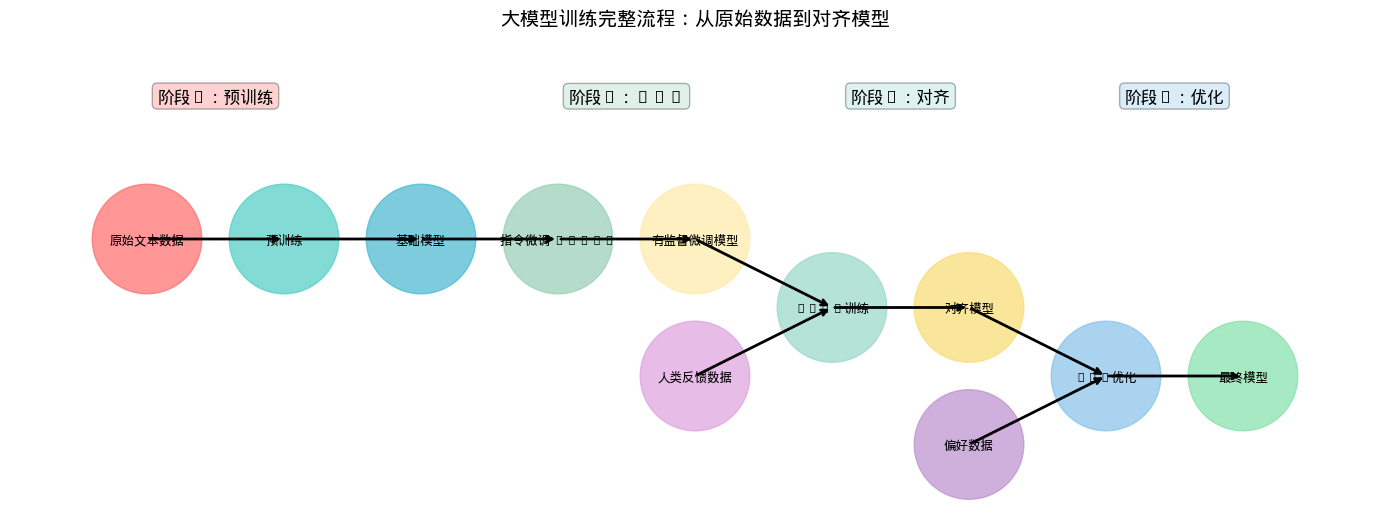


📊 训练阶段关键参数对比:


,阶段,数据量,目标,评估方式
0,预训练,TB级,语言模式学习,困惑度
1,SFT,万-百万级,指令遵循,指令准确率
2,RLHF,千-万级,对齐人类偏好,人类偏好
3,DPO,千级,直接优化,奖励模型


In [7]:
def training_pipeline_demo():
    """演示大模型训练完整流程"""
    print("🚀 大模型训练流程可视化")
    
    # 创建训练流程图
    fig, ax = plt.subplots(1, 1, figsize=(14, 8))
    
    # 定义流程节点
    nodes = [
        ('原始文本数据', 0, 4, '#FF6B6B'),
        ('预训练', 2, 4, '#4ECDC4'),
        ('基础模型', 4, 4, '#45B7D1'),
        ('指令微调 (SFT)', 6, 4, '#96CEB4'),
        ('有监督微调模型', 8, 4, '#FFEAA7'),
        ('人类反馈数据', 8, 2, '#DDA0DD'),
        ('RLHF训练', 10, 3, '#98D8C8'),
        ('对齐模型', 12, 3, '#F7DC6F'),
        ('偏好数据', 12, 1, '#BB8FCE'),
        ('DPO优化', 14, 2, '#85C1E9'),
        ('最终模型', 16, 2, '#82E0AA'),
    ]
    
    # 绘制节点
    for name, x, y, color in nodes:
        circle = plt.Circle((x, y), 0.8, color=color, alpha=0.7)
        ax.add_patch(circle)
        ax.text(x, y, name, ha='center', va='center', fontsize=9, weight='bold')
    
    # 添加连接线和箭头
    connections = [
        ((0, 4), (2, 4)), ((2, 4), (4, 4)), ((4, 4), (6, 4)),
        ((6, 4), (8, 4)), ((8, 4), (10, 3)), ((10, 3), (12, 3)),
        ((12, 3), (14, 2)), ((14, 2), (16, 2)),
        ((8, 2), (10, 3)), ((12, 1), (14, 2))
    ]
    
    for (x1, y1), (x2, y2) in connections:
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                   arrowprops=dict(arrowstyle='->', color='black', lw=2))
    
    # 添加阶段标签
    ax.text(1, 6, '阶段1：预训练', ha='center', fontsize=12, weight='bold', 
            bbox=dict(boxstyle='round', facecolor='#FF6B6B', alpha=0.3))
    ax.text(7, 6, '阶段2：SFT', ha='center', fontsize=12, weight='bold',
            bbox=dict(boxstyle='round', facecolor='#96CEB4', alpha=0.3))
    ax.text(11, 6, '阶段3：对齐', ha='center', fontsize=12, weight='bold',
            bbox=dict(boxstyle='round', facecolor='#98D8C8', alpha=0.3))
    ax.text(15, 6, '阶段4：优化', ha='center', fontsize=12, weight='bold',
            bbox=dict(boxstyle='round', facecolor='#85C1E9', alpha=0.3))
    
    ax.set_xlim(-2, 18)
    ax.set_ylim(0, 7)
    ax.set_aspect('equal')
    ax.set_title('大模型训练完整流程：从原始数据到对齐模型', fontsize=14, weight='bold')
    ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # 关键参数对比
    print("\n📊 训练阶段关键参数对比:")
    
    data = {
        '阶段': ['预训练', 'SFT', 'RLHF', 'DPO'],
        '数据量': ['TB级', '万-百万级', '千-万级', '千级'],
        '目标': ['语言模式学习', '指令遵循', '对齐人类偏好', '直接优化'],
        '评估方式': ['困惑度', '指令准确率', '人类偏好', '奖励模型']
    }
    
    df = pd.DataFrame(data)
    display(df)

import pandas as pd
training_pipeline_demo()

## 🧩 复习测试题

### 选择题

**1. 在Transformer中，自注意力机制的核心作用是什么？**
A. 减少模型参数数量
B. 捕捉序列中不同位置之间的依赖关系
C. 替代循环神经网络
D. 加速计算速度

**2. RoPE位置编码的主要优势是什么？
A. 相对位置信息
B. 绝对位置信息
C. 位置无关性
D. 计算效率高

**3. 大模型训练中，RLHF的主要目的是什么？**
A. 提升模型推理速度
B. 使模型输出更符合人类偏好
C. 减少训练数据量
D. 降低内存使用

**4. KV Cache的作用是什么？**
A. 存储模型权重
B. 缓存计算结果，避免重复计算
C. 存储训练数据
D. 存储超参数

**5. SFT（监督微调）与预训练的主要区别是什么？**
A. SFT使用更少的数据
B. SFT专注于特定任务或指令遵循
C. SFT不使用GPU
D. SFT只能用于小模型

In [8]:
def quiz_check():
    """复习答案检查"""
    correct_answers = ['B', 'A', 'B', 'B', 'B']
    explanations = [
        'B: 自注意力机制通过计算序列中所有位置之间的关系，捕捉长期依赖',
        'A: RoPE的优势是能同时捕捉相对位置信息，适合处理变长序列',
        'B: RLHF通过人类反馈强化学习，让模型输出更符合人类价值观和偏好',
        'B: KV Cache缓存Key-Value对，避免重复计算，大幅提升推理速度',
        'B: SFT是在预训练基础上，用特定指令数据进行微调，使模型遵循指令'
    ]
    
    print("📝 复习答案解析:")
    print("="*50)
    for i, (ans, exp) in enumerate(zip(correct_answers, explanations), 1):
        print(f"❓ 题目{i}: {exp}")
        print()
    
    print("💡 提示：回复答案后我可以帮你详细解析！")

quiz_check()

📝 复习答案解析:
❓ 题目1: B: 自注意力机制通过计算序列中所有位置之间的关系，捕捉长期依赖

❓ 题目2: A: RoPE的优势是能同时捕捉相对位置信息，适合处理变长序列

❓ 题目3: B: RLHF通过人类反馈强化学习，让模型输出更符合人类价值观和偏好

❓ 题目4: B: KV Cache缓存Key-Value对，避免重复计算，大幅提升推理速度

❓ 题目5: B: SFT是在预训练基础上，用特定指令数据进行微调，使模型遵循指令

💡 提示：回复答案后我可以帮你详细解析！


## 💡 关键概念总结

### 知识卡片：本周精华

**卡片1：自注意力机制**
- 核心：Q、K、V三个矩阵相乘
- 优势：并行计算，捕捉长距离依赖
- 应用：Transformer架构的基础

**卡片2：位置编码**
- RoPE：相对位置编码，适合变长序列
- ALiBi：线性位置编码，计算效率高
- 作用：给模型提供位置信息

**卡片3：推理优化**
- KV Cache：避免重复计算
- Flash Attention：内存友好的注意力计算
- GQA：分组查询，平衡精度和效率

**卡片4：训练流程**
- 预训练：大规模无监督学习
- SFT：指令微调，教会模型遵循指令
- RLHF：人类反馈对齐，输出符合偏好
- DPO：直接偏好优化，简化对齐流程

**卡片5：超参数调优**
- 学习率：最重要的超参数
- 批次大小：影响训练稳定性
- 训练轮数：防止过拟合和欠拟合
- 优化器：Adam、AdamW等

## 🔗 跨领域关联思考

### 脑科学与AI的交叉视角

1. **注意力机制 vs 大脑注意力网络**
   - Transformer自注意力 ↔ 大脑背侧注意网络
   - 并行处理 ↔ 大脑多模态整合
   - 位置信息 ↔ 海马体空间编码

2. **训练过程 vs 神经可塑性**
   - 预训练 ↔ 神经基础连接建立
   - 微调 ↔ 突触可塑性
   - 对齐 ↔ 价值观形成

3. **推理优化 vs 大脑效率**
   - KV Cache ↔ 工作记忆缓存
   - Flash Attention ↔ 快速决策模式
   - 量化压缩 ↔ 神经元信息压缩

## 🎯 下周预告

### 第4周：RAG与知识增强

📚 **核心主题：** 让大模型能够利用外部知识库

🎯 **学习目标：**
- 理解RAG基本架构和流程
- 掌握向量检索和相似度计算
- 学会搭建完整的RAG系统
- 实际部署和应用RAG

⚡ **周六实战：** 本地搭建RAG系统
- 用sentence-transformers做Embedding
- ChromaDB作为向量数据库
- 本地Qwen2-7B推理
- 导入技术文档进行问答

📖 **关键概念：**
- 向量嵌入 (Embedding)
- 相似度计算
- 检索增强生成
- 混合检索策略
- 查询改写和重排序

🔗 **学习资源：**
- Hugging Face RAG教程
- LangChain文档
- ChromaDB官方文档

💡 **预习建议：**
- 了解基本的向量数据库概念
- 熟悉相似度计算方法
- 准备一份自己的技术文档作为测试数据

In [9]:
print("🎉 第3周复习完成！")
print("\n📊 学习统计：")
print("• W1：Transformer基础架构 → 5个核心概念")
print("• W2：Transformer深入理解 → 5个优化技术")
print("• W3：大模型训练全景 → 4个训练阶段")
print("• 总计：14个核心知识点 + 5个实战技术")
print("\n🚀 准备好进入第4周：RAG与知识增强！")

# 生成学习报告
print("\n📈 学习进度：3/12 周完成")
progress = 3/12
filled = int(progress * 20)
empty = 20 - filled
print(f"进度条: [{'█' * filled}{'░' * empty}] {progress:.0%}")

🎉 第3周复习完成！

📊 学习统计：
• W1：Transformer基础架构 → 5个核心概念
• W2：Transformer深入理解 → 5个优化技术
• W3：大模型训练全景 → 4个训练阶段
• 总计：14个核心知识点 + 5个实战技术

🚀 准备好进入第4周：RAG与知识增强！

📈 学习进度：3/12 周完成
进度条: [█████░░░░░░░░░░░░░░░] 25%
